In [1]:
import os.path  as op
from os import listdir
import matplotlib
from matplotlib import pyplot as plt
import nilearn
import nibabel as nib
import numpy as np
import nilearn.plotting as nipl 
import nilearn.image as niim
import matplotlib as mpl

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [3]:
def get_2ndlevel_spm(model, version, con, bids_folder, specification='con', num=1):
    spm_file = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_{specification}_2ndlevels',f'2ndlevel_{model}-{version}_{con}',f'spmT_000{num}.nii')
    spm = nib.load(spm_file)
    return spm


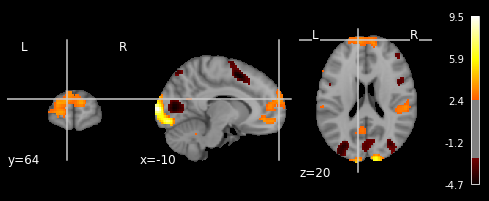

In [8]:
# plot anat and then func
model = 'NLC'
version = 3
con = 'v2_ch'

anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

coords = [-10, 64, 20]
display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
display.add_overlay(spm, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['hot'])


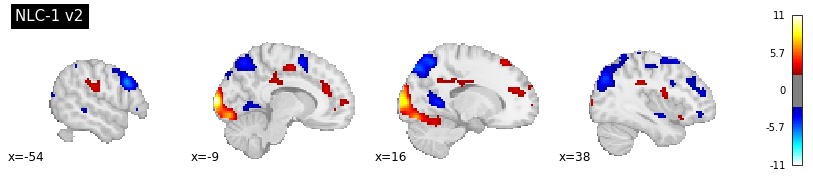

In [21]:
# automatically plot func in standard space

model = 'NLC'
version = '1'
contrast = 'v2'
spm= get_2ndlevel_spm(model=model, version=version, con=contrast, bids_folder=bids_folder)
nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'{model}-{version} {contrast}', display_mode='x', cut_coords =4 )


In [4]:
# loop on different contrast of 2nd-level-SPMs
# create and safe 

model = 'NLC'
version = '4'
specification = 'bothSess1stlevel_2sTTest' #'con'
model_folder = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_{specification}_2ndlevels')
if model == 'EU' or model=='EV' and version != '3b':
    cons = [f[14:] for f in listdir(model_folder)]
else:
    cons = [f[15:] for f in listdir(model_folder)]


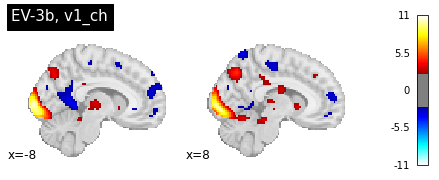

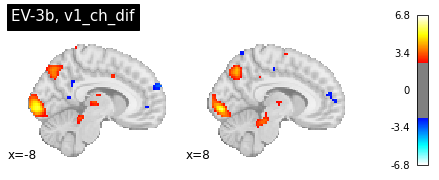

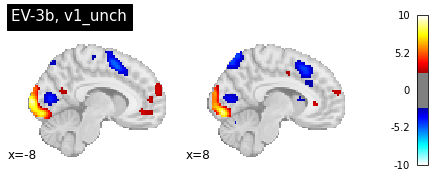

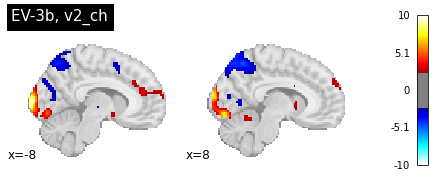

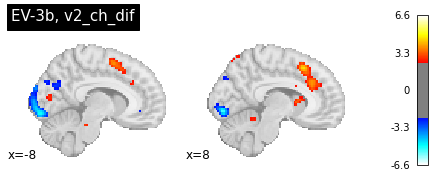

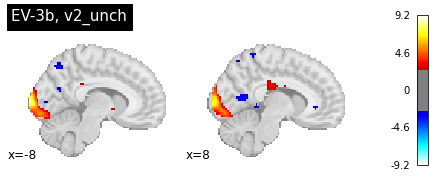

In [27]:
model = 'EV'
version = '3b'
cut_coords = tuple([-8,8]) # vmMPFC coordinates?
# version = 3, cons = ['v1_ch', 'v1_ch_dif', 'v1_unch', 'v2_ch', 'v2_ch_dif', 'v2_unch']

specification = 'con' # 'bothSess1stlevel_2sTTest' #
model_folder = op.join(bids_folder,'derivatives', 'spm', f'{model}-{version}_{specification}_2ndlevels')
if model == 'EU' or model=='EV' and version != '3b':
    cons = [f[14:] for f in listdir(model_folder)]
else:
    cons = [f[15:] for f in listdir(model_folder)]

for con in cons:
    spm= get_2ndlevel_spm(model=model, version=version, con=con, bids_folder=bids_folder, specification=specification)
    disp = nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'{model}-{version}, {con}', display_mode='x', cut_coords=cut_coords)
    out_file = op.join(bids_folder,'figures','spm_2ndlevels', f'{model}-{version}_{specification}_{con}')
    disp.savefig(out_file ,dpi=199)


In [ ]:
# for NLC-4, both sesssion different groups 1&2-sample-TTests

con = cons[3]
print(con)
num_names = ['stressed, 1sTT', 'stressed, 2sTT', 'control, 1sTT', 'control, 2sTT']
for num in range(1,5):
    spm= get_2ndlevel_spm(model=model, version=version, con=con, bids_folder=bids_folder, specification=specification, num=num)
    disp = nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'{model}-{version}, {con}, {num_names[num-1]}', display_mode='x', cut_coords=4)


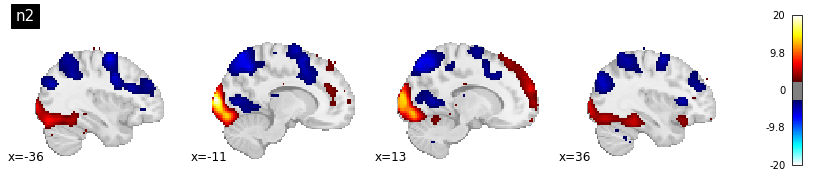

In [18]:
# pure numerosities
num = 2
con = f'n{num}'
model_n = 'pure num'
spm = nib.load(f'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/spm/2ndlevel_num_{num}/spmT_0001.nii')
disp = nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False, title=f'n{num}', display_mode='x', cut_coords=4)


In [ ]:
# plot on surface: right
from nilearn import datasets, surface
fsaverage = datasets.fetch_surf_fsaverage()
curv_right = surface.load_surf_data(fsaverage.curv_right)
curv_right_sign = np.sign(curv_right)

texture = surface.vol_to_surf(spm, fsaverage.pial_right)

nipl.plot_surf_stat_map(surf_mesh= fsaverage.infl_right,stat_map= texture, 
    view='medial',
    hemi='right',
    title=f'{model_n}, {con}', colorbar=True,
    threshold=2.5, bg_map=curv_right_sign) # bg_map: Background image to be plotted on the mesh underneath the stat_map in greyscale

In [ ]:
# plot on surface: left

from nilearn import datasets, surface
fsaverage = datasets.fetch_surf_fsaverage()
curv_left = surface.load_surf_data(fsaverage.curv_left)
curv_left_sign = np.sign(curv_left)

texture = surface.vol_to_surf(spm, fsaverage.pial_left)

nipl.plot_surf_stat_map(surf_mesh= fsaverage.infl_left,stat_map= texture, 
    view='anterior',
    hemi='left',
    title=f'{model_n}, {con}', colorbar=True,
    threshold=2.5, bg_map=curv_left_sign) # bg_map: Background image to be plotted on the mesh underneath the stat_map in greyscale

In [18]:
np.shape(spm.get_fdata()) # memmap, (78, 93, 65)

(78, 93, 65)

In [24]:
187.05 + 306 + 62.55 + 158.85 

714.45